# Model #

I try to put down a model. I will use the xor-perceptron model as a base and modify that.

first create the lattice, N by N, with Nsol = N**2

I should create a class for the cell object and then the network class is formed by cell objects and when the network is created, each network is associated with a position in the lattice.

Note: for now I'm only considering one possible link between each pair neuron for each direction

In [1]:
import numpy as np
from numpy import random as nrd
import matplotlib.pyplot as plt
import graph_tool as gt
from graph_tool.all import *
import copy

import model as m       # I've put all the functions in a separate Python file


(ipykernel_launcher.py:170264): dbind-WARNING **: 17:17:58.707: AT-SPI: Error retrieving accessibility bus address: org.freedesktop.DBus.Error.ServiceUnknown: The name org.a11y.Bus was not provided by any .service files


In [2]:
# parameters of the simulation
par={'N': 10,                    # side length of the squared lattice
     'int_range': 1,             # interaction range
     'p_self_link': 0,         # probability for each cell of having a self link
     'J_range': [-1,+1],                       # define the possible value for J.
     'J_mutation_radius': 0.1,                 # standard deviation of the normal distribution used to sample the mutation value for J.
     'B_mutation_radius': 0.1,            # standard deviation of the normal distribution used to sample the mutation value for B.
     'T_mutation_radius': 0.1,           # standard deviation of the normal distribution used to sample the mutation value for T.
     'reproduction_ratio': 0.8,          # percentage of offsprings to be generated by reproduction (the reamining by random generation)
     'length_powerlaw': 1,         # exponent of the wire length power law (DA DEFINIRE!!!)
     'x_n': np.linspace(-1,1,512),   # discretization of the input of the transfer function (last argmument 
                                   # is also the maximum number of non-zero coefficients in the DFT of the 
                                   # transfer function. it should be a power of 2 for best performance of fft)
     'T_initial': lambda x: 0+1*x,              # initial transfer function shape (here linear)
     'target_set': [0.0,1.0,1.0,0.0],
     'input_set':[[0,0],[0,1],[1,0],[1,1]],
     'n_iter': 100,
     'N_sol': 50}                       # number of solutions (individuals, networks) considered in the simulation

nrd.seed(1234)

In [3]:
solutions, fmean = m.evolution(par,verb=2,gen_verb=False)

Iteration #0...
Mean fitness: 4776557458055.004
Iteration #10...
Mean fitness: 2.704584681467684e+42
Iteration #20...
Mean fitness: 1.248381086720313e+42
Iteration #30...
Mean fitness: 1.1532033545666025e+40
Iteration #40...
Mean fitness: 7.844933909501155e+40
Iteration #50...
Mean fitness: 2.6231996501808884e+40
Iteration #60...
Mean fitness: 6.191443948931003e+40
Iteration #70...
Mean fitness: 1.652878235055098e+42
Iteration #80...
Mean fitness: 5.888058539267171e+39
Iteration #90...
Mean fitness: 1.2265208707514442e+41


In [5]:
s = copy.deepcopy(solutions)
for sol in s[:20]:
    fitness,_ = m.compute_fitness(sol,par,True)
    print(f'Fitness:{fitness}')

Input: [0, 0] -> Output: 7.528411634556337e+52
Target distance:5.667698173932321e+105
Volume cost:0.0729
Length cost:0.18568264462809916
Path cost:2.997794929088869
Input: [0, 1] -> Output: 8.573610094751263e+164
Target distance:inf
Volume cost:0.0729
Length cost:0.18568264462809916
Path cost:2.997794929088869
Input: [1, 0] -> Output: inf
Target distance:inf
Volume cost:0.0729
Length cost:0.18568264462809916
Path cost:2.997794929088869
Input: [1, 1] -> Output: nan
Target distance:nan
Volume cost:0.0729
Length cost:0.18568264462809916
Path cost:2.997794929088869
Fitness:nan
Input: [0, 0] -> Output: 7.533362255729677e+52
Target distance:5.675154687605252e+105
Volume cost:0.06987745128048158
Length cost:0.17776018773594532
Path cost:3.020924895418835
Input: [0, 1] -> Output: -7.375370024023655e+169
Target distance:inf
Volume cost:0.06987745128048158
Length cost:0.17776018773594532
Path cost:3.020924895418835
Input: [1, 0] -> Output: -inf
Target distance:inf
Volume cost:0.06987745128048158

/home/pietromalagoli/ne/main/model.py:72: RuntimeWarning: overflow encountered in scalar power
  target_dist = (par['target_set'][i] - output)**2                            # square distance between network output and target (theoretical) output
/home/pietromalagoli/miniconda3/envs/uni/lib/python3.12/site-packages/numpy/lib/polynomial.py:780: RuntimeWarning: overflow encountered in multiply
  y = y * x + pv


Input: [1, 1] -> Output: nan
Target distance:nan
Volume cost:0.06754748495051525
Length cost:0.16992716049382714
Path cost:3.0402677685950414
Fitness:nan
Input: [0, 0] -> Output: -2.0672377689755904e+56
Target distance:4.273471993479176e+112
Volume cost:0.07068078767472706
Length cost:0.17835691255994288
Path cost:3.0153094684215898
Input: [0, 1] -> Output: -2.0416259757777033e+167
Target distance:inf
Volume cost:0.07068078767472706
Length cost:0.17835691255994288
Path cost:3.0153094684215898
Input: [1, 0] -> Output: -inf
Target distance:inf
Volume cost:0.07068078767472706
Length cost:0.17835691255994288
Path cost:3.0153094684215898
Input: [1, 1] -> Output: nan
Target distance:nan
Volume cost:0.07068078767472706
Length cost:0.17835691255994288
Path cost:3.0153094684215898
Fitness:nan
Input: [0, 0] -> Output: -4.0798479946094237e+54
Target distance:1.6645159659118535e+109
Volume cost:0.06760000000000001
Length cost:0.17184793388429753
Path cost:3.038506774818896
Input: [0, 1] -> Output:

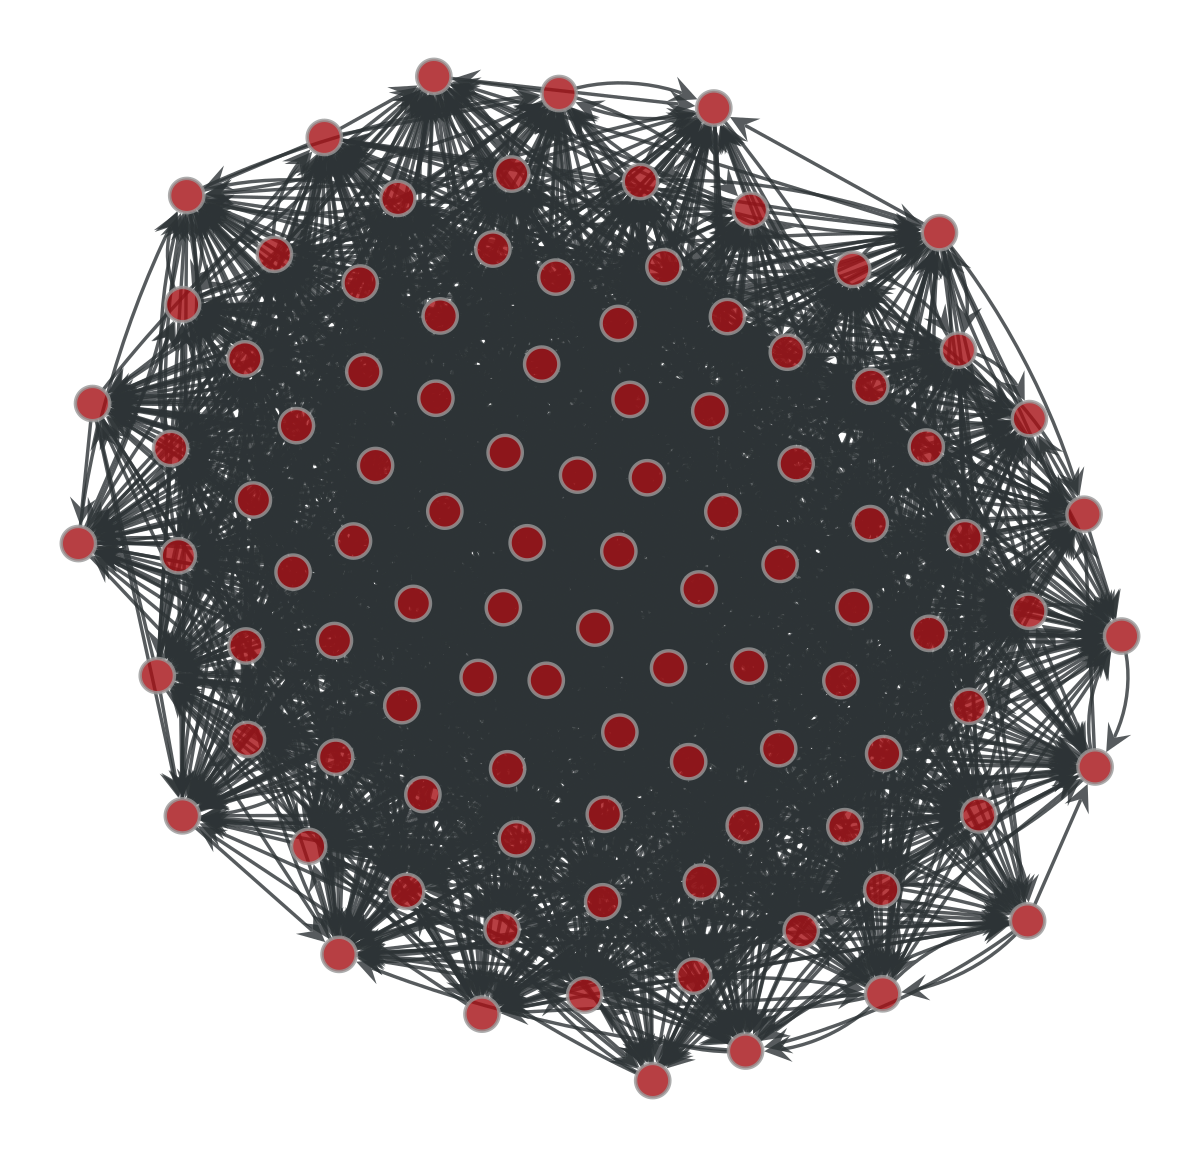

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7dad1e7c0440, at 0x7dad29139370>

In [6]:
graph_draw(s[0].G)

In [10]:
print(s[0].C.shape)
print(np.sum(s[0].C)/s[0].C.shape[0]**2)

(100, 100)
0.2673


In [ ]:
m.plot_T(solutions[0].T[1],par)

In [ ]:
plt.plot(fmean)

In [ ]:
n1 = m.generate(par)
n2 = m.generate(par)

o1, o2 = m.crossover(n1,n2)